## Set-up ENV & CUDA (GPU)

In [ ]:
# conda install pytorch torchvision torchaudio pytorch-cuda=11.8 -c pytorch -c nvidia
# pip install jupyter matplotlib notebook opencv-python pandas scikit-learn

In [62]:
import os, sys, cv2, random, numpy as np, pandas as pd

import torch
torch.cuda.is_available()

True

In [63]:
def get_size(bytes, suffix="B"):
    factor = 1024
    for unit in ["", "K", "M", "G", "T", "P"]:
        if bytes < factor:
            return f"{bytes:.2f}{unit}{suffix}"
        bytes /= factor

print(f"🐍 Python Version     : {sys.version.split()[0]}")
print(f"🔥 PyTorch Version    : {torch.__version__}")
print(f"🧊 CUDA (di PyTorch)  : {torch.version.cuda}")
print(f"🧠 cuDNN Version      : {torch.backends.cudnn.version()}")
print(f"📷 OpenCV Version     : {cv2.__version__}")
print(f"🐼 Pandas Version     : {pd.__version__}")

🐍 Python Version     : 3.10.19
🔥 PyTorch Version    : 2.5.1
🧊 CUDA (di PyTorch)  : 11.8
🧠 cuDNN Version      : 90100
📷 OpenCV Version     : 4.12.0
🐼 Pandas Version     : 2.3.3


In [64]:
if torch.cuda.is_available():
    print(f"✅ GPU TERDETEKSI     : YA")
    print(f"🆔 Jumlah GPU         : {torch.cuda.device_count()}")

    # Loop untuk melihat detail setiap GPU (biasanya cuma 1)
    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_props = torch.cuda.get_device_properties(i)

        print(f"\n--- GPU {i}: {gpu_name} ---")
        print(f"💾 Total VRAM         : {get_size(gpu_props.total_memory)}")
        print(f"⚡ Compute Capability : {gpu_props.major}.{gpu_props.minor}")

        # Test Alokasi Memori Kecil
        print("🧪 Test Tensor        : Berhasil memindahkan tensor ke GPU", end="")
        try:
            x = torch.tensor([1.0, 2.0]).cuda()
            print(" (OK)")
        except Exception as e:
            print(f" (GAGAL: {e})")
else:
    print("❌ GPU TIDAK TERDETEKSI. Cek instalasi CUDA/Driver Anda.")

✅ GPU TERDETEKSI     : YA
🆔 Jumlah GPU         : 1

--- GPU 0: NVIDIA GeForce GTX 1650 ---
💾 Total VRAM         : 4.00GB
⚡ Compute Capability : 7.5
🧪 Test Tensor        : Berhasil memindahkan tensor ke GPU (OK)


In [65]:
def set_seed(seed=42):
    """
    Mengunci semua faktor acak agar hasil training bisa direproduksi (konsisten).
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Setting agar algoritma CUDA deterministik
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random Seed dikunci di: {seed}")

set_seed(42)

Random Seed dikunci di: 42


## Preprocessing

In [66]:
import os, shutil, warnings
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False

In [67]:
DATASET_PATH = "data/Cats-vs-Dogs/PetImages"
CORRUPT_PATH = "data/Cats-vs-Dogs/CorruptImages"

In [68]:
def quarantine_strict(root_dir, quarantine_dir):
    print(f"🧹 Memulai pembersihan KETAT di: {root_dir}")
    print(f"📦 File bermasalah pindah ke: {quarantine_dir}")

    moved_count = 0

    if not os.path.exists(quarantine_dir):
        os.makedirs(quarantine_dir)

    for category in ["Cat", "Dog"]:
        src_folder = os.path.join(root_dir, category)
        dst_folder = os.path.join(quarantine_dir, category)

        if not os.path.exists(dst_folder):
            os.makedirs(dst_folder)

        if not os.path.exists(src_folder):
            continue

        files = os.listdir(src_folder)
        print(f"📂 Mengecek {len(files)} file di folder {category}...")

        for filename in files:
            file_path = os.path.join(src_folder, filename)

            if os.path.isdir(file_path):
                continue

            is_corrupt = False
            error_msg = ""

            try:
                with warnings.catch_warnings(record=True) as w:
                    warnings.simplefilter("error", UserWarning)
                    warnings.simplefilter("error", Image.DecompressionBombWarning)

                    with Image.open(file_path) as img:
                        img.verify()
                        with Image.open(file_path) as img2:
                            img2.load()

            except (IOError, SyntaxError, OSError, UserWarning, Warning) as e:
                is_corrupt = True
                error_msg = str(e)

            if is_corrupt:
                dst_path = os.path.join(dst_folder, filename)
                print(f"   ❌ Isu ditemukan ({error_msg}) -> Memindahkan: {filename}")

                try:
                    shutil.move(file_path, dst_path)
                    moved_count += 1
                except Exception as move_error:
                    print(f"   ⚠️ Gagal pindah {filename}: {move_error}")

    print(f"✅ Selesai! Total file dikarantina: {moved_count}")

quarantine_strict(DATASET_PATH, CORRUPT_PATH)

🧹 Memulai pembersihan KETAT di: data/Cats-vs-Dogs/PetImages
📦 File bermasalah pindah ke: data/Cats-vs-Dogs/CorruptImages
📂 Mengecek 12501 file di folder Cat...
   ❌ Isu ditemukan (cannot identify image file 'data/Cats-vs-Dogs/PetImages\\Cat\\666.jpg') -> Memindahkan: 666.jpg
   ❌ Isu ditemukan (cannot identify image file 'data/Cats-vs-Dogs/PetImages\\Cat\\Thumbs.db') -> Memindahkan: Thumbs.db
📂 Mengecek 12501 file di folder Dog...
   ❌ Isu ditemukan (cannot identify image file 'data/Cats-vs-Dogs/PetImages\\Dog\\11702.jpg') -> Memindahkan: 11702.jpg
   ❌ Isu ditemukan (Truncated File Read) -> Memindahkan: 9041.jpg
   ❌ Isu ditemukan (cannot identify image file 'data/Cats-vs-Dogs/PetImages\\Dog\\Thumbs.db') -> Memindahkan: Thumbs.db
✅ Selesai! Total file dikarantina: 5


In [ ]:
# from PIL import Image
# Image.open("data/Cats-vs-Dogs/CorruptImages/Dog/9041.jpg").load()

## Data Splitting

In [75]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset

BATCH_SIZE = 32
IMG_SIZE = (128, 128)

In [76]:
# --- 1. DEFINISIKAN DUA JENIS TRANSFORMASI ---

# A. Transformasi Training (Agresif untuk cegah Overfitting)
train_transform = transforms.Compose([
    # Paksa convert ke RGB agar tidak crash di gambar Grayscale
    transforms.Lambda(lambda x: x.convert("RGB")),

    # Augmentasi Data (Mempersulit model belajar)
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5), # Kadang dibalik kiri-kanan
    transforms.RandomRotation(degrees=15),  # Kadang dimiringkan dikit
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Ubah pencahayaan

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# B. Transformasi Validasi (Bersih & Standar)
val_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")), # Tetap convert RGB
    transforms.Resize(IMG_SIZE),                   # Resize saja
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [77]:
# --- 2. LOAD DATASET MENTAH ---
raw_dataset = datasets.ImageFolder(root=DATASET_PATH)

# --- 3. SPLIT DATA (80/20) ---
total_count = len(raw_dataset)
train_count = int(0.8 * total_count)
val_count = total_count - train_count

# Split indices-nya saja
train_subset, val_subset = random_split(raw_dataset, [train_count, val_count])

# --- 4. CLASS WRAPPER (PENTING) ---
class DatasetFromSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index] # Ambil gambar raw
        if self.transform:
            x = self.transform(x) # Terapkan transform khusus (Train/Val)
        return x, y

    def __len__(self):
        return len(self.subset)

# Bungkus subset dengan transform masing-masing
train_data = DatasetFromSubset(train_subset, transform=train_transform)
val_data = DatasetFromSubset(val_subset, transform=val_transform)

In [78]:
# --- 5. BUAT DATALOADER ---
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total Gambar : {total_count}")
print(f"Data Latih   : {len(train_data)} (Dengan Augmentasi)")
print(f"Data Validasi: {len(val_data)} (Bersih/Tanpa Augmentasi)")
print(f"Kelas        : {raw_dataset.class_to_idx}")

Total Gambar : 24997
Data Latih   : 19997 (Dengan Augmentasi)
Data Validasi: 5000 (Bersih/Tanpa Augmentasi)
Kelas        : {'Cat': 0, 'Dog': 1}


In [72]:
import matplotlib.pyplot as plt
import numpy as np

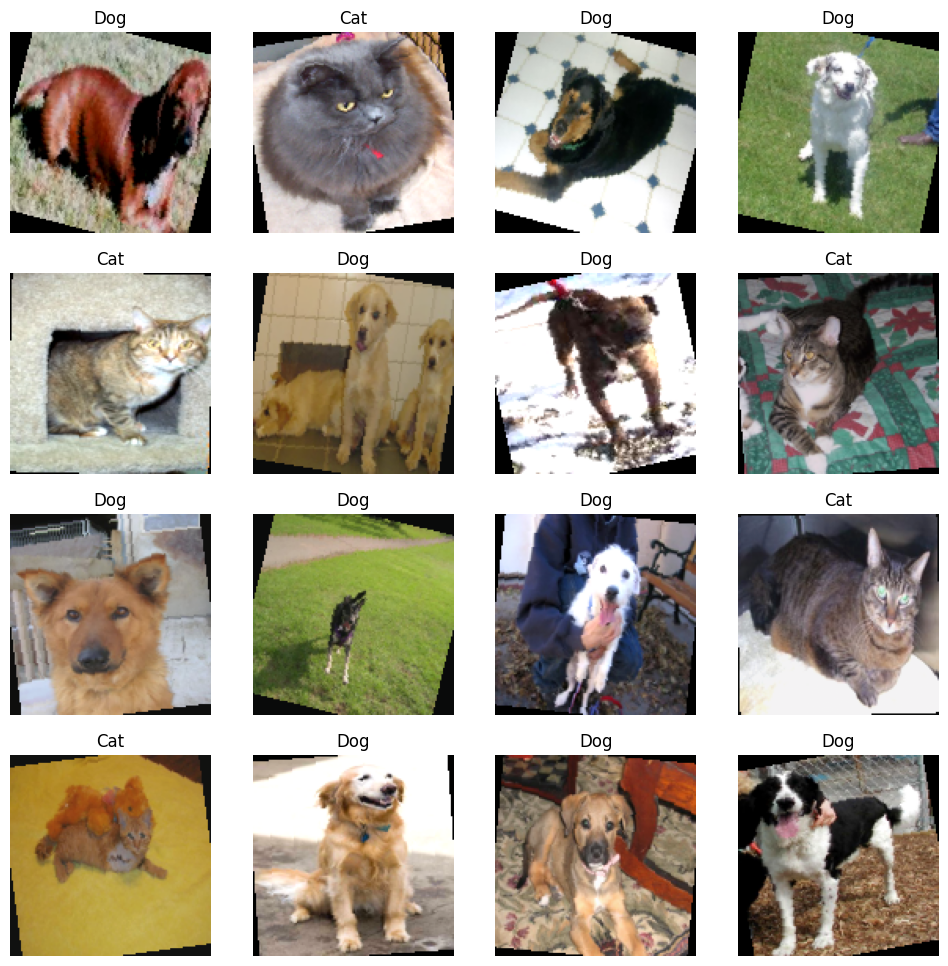

In [84]:
def imshow(img):
    # Undo normalisasi
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(img)
    img = img.numpy()

    plt.imshow(np.transpose(img, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)
class_names = ['Cat', 'Dog']

plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)
    imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.show()

## Arsitektur Model (CNN Modern)

In [85]:
import torch.nn as nn
import torch.nn.functional as F

In [87]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()

        # --- BLOK 1: Ekstraksi Fitur Awal (Detail Kasar: Garis, Sudut) ---
        # Input: 3 channel (RGB) -> Output: 32 filter
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Penstabil
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Perkecil ukuran gambar (128->64)

        # --- BLOK 2: Ekstraksi Fitur Menengah (Bentuk: Mata, Telinga) ---
        # Input: 32 -> Output: 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # MaxPool lagi (64->32)

        # --- BLOK 3: Ekstraksi Fitur Kompleks (Wajah utuh) ---
        # Input: 64 -> Output: 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        # MaxPool lagi (32->16)

        # --- BLOK 4: Deep Features (Abstrak) ---
        # Input: 128 -> Output: 128 (Kita tahan di 128 biar hemat VRAM)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        # MaxPool lagi (16->8)

        # --- CLASSIFIER (Otak Pengambil Keputusan) ---
        # Gambar sekarang ukurannya 8x8 dengan tebal 128 layer
        # Flatten: 128 * 8 * 8 = 8192 neuron
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.dropout = nn.Dropout(0.5) # KUNCI ANTI-OVERFITTING (Matikan 50% neuron acak)
        self.fc2 = nn.Linear(512, 2)   # Output: 2 (Cat atau Dog)

    def forward(self, x):
        # Alur Maju (Forward Pass)

        # Blok 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Blok 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Blok 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Blok 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # Ratakan (Flatten) dari gambar 3D ke vektor 1D
        x = x.view(-1, 128 * 8 * 8)

        # Masuk ke Neural Network biasa
        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Terapkan Dropout di sini
        x = self.fc2(x)

        return x

# Inisialisasi Model ke GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CatDogCNN().to(device)

print("Model berhasil dibuat dan masuk ke GPU!")
# print(model)

Model berhasil dibuat dan masuk ke GPU!


## Training

In [92]:
import time
import torch.optim as optim

In [93]:
# HYPERPARAMETER
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
PATIENCE = 5

# Variabel Global
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
patience_counter = 0 # Menghitung berapa kali gagal membaik

In [94]:
# 1. Loss Function
criterion = nn.CrossEntropyLoss()

# 2. Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. Scheduler (REVISI: verbose=True dihapus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

In [95]:
print(f"Memulai Training pada perangkat: {device}")
print(f"Target: {NUM_EPOCHS} Epochs (dengan Early Stopping)")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # ==========================
    #      FASE 1: TRAINING
    # ==========================
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Reset -> Forward -> Loss -> Backward -> Update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistik
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct_train / total_train

    # ==========================
    #      FASE 2: VALIDASI
    # ==========================
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    # Simpan History
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    # Update Scheduler (Cek apakah perlu turunkan Learning Rate?)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)

    # ==========================
    #      REPORT & SAVING
    # ==========================
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {current_lr}")

    # LOGIKA SAVE BEST MODEL
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'model_terbaik.pth')
        print(f"   --> 🏆 Rekor Baru! Model disimpan.")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   --> Tidak ada peningkatan ({patience_counter}/{PATIENCE})")

    # LOGIKA EARLY STOPPING
    if patience_counter >= PATIENCE:
        print(f"\n🛑 Early Stopping dipicu! Training berhenti di Epoch {epoch+1}.")
        break

total_time = time.time() - start_time
print(f"\n✅ Selesai! Waktu total: {total_time/60:.2f} menit")
print(f"🏅 Akurasi Validasi Tertinggi: {best_acc:.2f}%")

# Load kembali model terbaik
print("📥 Memuat kembali model terbaik untuk sesi testing...")
model.load_state_dict(torch.load('model_terbaik.pth'))

Memulai Training pada perangkat: cuda
Target: 25 Epochs (dengan Early Stopping)
Epoch [1/25] Loss: 0.6393 | Acc: 64.02% | Val Loss: 0.5860 | Val Acc: 68.94% | LR: 0.001
   --> 🏆 Rekor Baru! Model disimpan.
Epoch [2/25] Loss: 0.5477 | Acc: 73.12% | Val Loss: 0.5808 | Val Acc: 73.02% | LR: 0.001
   --> 🏆 Rekor Baru! Model disimpan.
Epoch [3/25] Loss: 0.4821 | Acc: 77.19% | Val Loss: 0.4147 | Val Acc: 81.34% | LR: 0.001
   --> 🏆 Rekor Baru! Model disimpan.
Epoch [4/25] Loss: 0.4320 | Acc: 80.74% | Val Loss: 0.3599 | Val Acc: 83.56% | LR: 0.001
   --> 🏆 Rekor Baru! Model disimpan.
Epoch [5/25] Loss: 0.3932 | Acc: 82.88% | Val Loss: 0.3826 | Val Acc: 83.92% | LR: 0.001
   --> 🏆 Rekor Baru! Model disimpan.
Epoch [6/25] Loss: 0.3512 | Acc: 85.22% | Val Loss: 0.3002 | Val Acc: 87.06% | LR: 0.001
   --> 🏆 Rekor Baru! Model disimpan.
Epoch [7/25] Loss: 0.3272 | Acc: 86.47% | Val Loss: 0.3921 | Val Acc: 82.86% | LR: 0.001
   --> Tidak ada peningkatan (1/5)
Epoch [8/25] Loss: 0.2996 | Acc: 87.91% 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6596\2754546110.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model_terbaik.pth'

<All keys matched successfully>

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Mapping kelas (sesuai output training tadi: Cat=0, Dog=1)
class_names = ['CAT', 'DOG']

def prediksi_gambar(image_path):
    # 1. Pastikan file ada
    if not os.path.exists(image_path):
        print(f"❌ File tidak ditemukan: {image_path}")
        return

    # 2. Buka Gambar
    img = Image.open(image_path)

    # 3. Preprocessing (HARUS SAMA PERSIS dengan Validation Transform)
    #    Resize -> Convert RGB -> ToTensor -> Normalize
    transform_prediksi = val_transform

    # Tambahkan dimensi batch (karena model butuh [1, 3, 128, 128])
    img_tensor = transform_prediksi(img).unsqueeze(0).to(device)

    # 4. Prediksi
    model.eval() # Mode evaluasi (matikan dropout)
    with torch.no_grad():
        outputs = model(img_tensor)

        # Hitung probabilitas (keyakinan)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, predicted = torch.max(probs, 1)

    # 5. Tampilkan Hasil
    pred_label = class_names[predicted.item()]
    confidence = conf.item() * 100

    print(f"📂 File      : {image_path}")
    print(f"🤖 Prediksi  : {pred_label}")
    print(f"📊 Keyakinan : {confidence:.2f}%")

    # (Opsional) Tampilkan gambar
    plt.imshow(img)
    plt.title(f"Prediksi: {pred_label} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

📂 File      : ./img/alpha-dog.jpg
🤖 Prediksi  : DOG
📊 Keyakinan : 77.67%


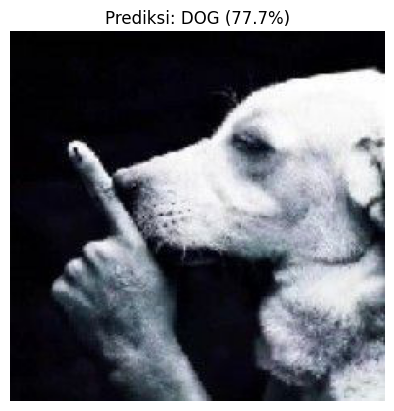

📂 File      : ./img/cooked-dog.jpg
🤖 Prediksi  : DOG
📊 Keyakinan : 71.28%


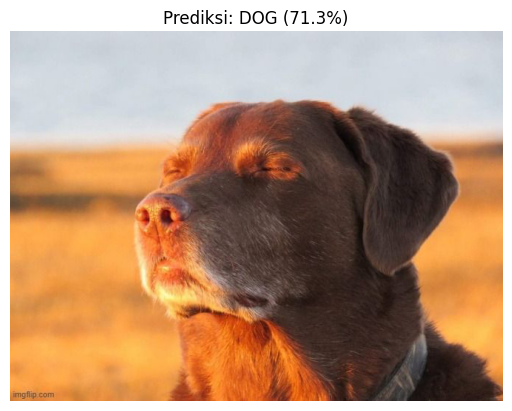

📂 File      : ./img/cukurukuk-cat.jpg
🤖 Prediksi  : DOG
📊 Keyakinan : 86.39%


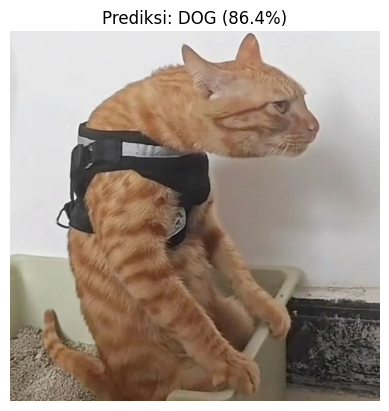

📂 File      : ./img/sigma-cat.jpg
🤖 Prediksi  : CAT
📊 Keyakinan : 99.81%


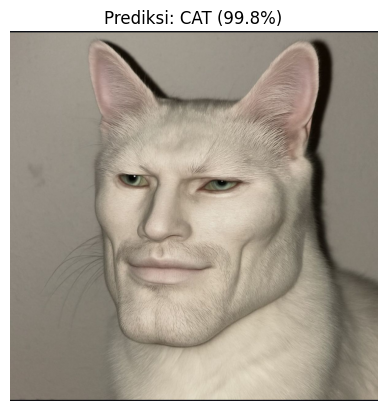

In [100]:
# --- JALANKAN TES ---
prediksi_gambar("./img/alpha-dog.jpg")
prediksi_gambar("./img/cooked-dog.jpg")
prediksi_gambar("./img/cukurukuk-cat.jpg")
prediksi_gambar("./img/sigma-cat.jpg")